---
## 순환 그래프 — AI끼리 대화 시켜보기

15.2의 **A ↔ B ↔ judge** 순환 구조에 LangChain LLM을 넣습니다.

| Node | 역할 |
|------|------|
| `optimist` | 낙관론자 — 주제에 찬성·긍정 |
| `skeptic` | 회의론자 — 반박·비판 |

**중단 조건** (`debate_route`):
* `turn_count >= max_turns` → `END`
* 마지막 메시지에 `'패배 인정'` 포함 → `END`
* 그 외 → `optimist`로 돌아가 순환

In [2]:
from pathlib import Path
from dotenv import load_dotenv

load_dotenv()
OPENAI_API_KEY = __import__('os').getenv('OPENAI_API_KEY')

WORKDIR = Path.cwd()
print('WORKDIR :', WORKDIR)

WORKDIR : /Users/user/Desktop/cursor 연습/16일차_실습


In [3]:
from typing import Literal, Annotated
from pydantic import BaseModel, Field
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langgraph.graph.message import add_messages
from langchain_openai import ChatOpenAI

class DebateState(BaseModel):
    chat_history: Annotated[list[BaseMessage], add_messages] = Field(default_factory=list)
    topic: str
    turn_count: int = 0
    max_turns: int = 3
    last_speaker: Literal['optimist', 'skeptic'] = 'skeptic'


llm = ChatOpenAI(model='gpt-4o-mini', temperature=0.8, api_key=OPENAI_API_KEY)

In [4]:
def optimist_node(state: DebateState) -> dict:
    prompts = [
        SystemMessage(content=(
            "당신은 세계 최고의 AI 토론가입니다."
            "주어지는 주제에 '찬성' 입장에서 토론에 참가하세요."
            "상대 AI 토론자의 의견에 조리 있게 두 문장 이내로 반박하세요"
            "응답에 '패배 인정'을 포함하면 패배를 인정하고 토론을 끝낼 수 있습니다."
        )),
    ]
    if not state.chat_history:
        prompts.append(HumanMessage(content=f'토론 주제는 {state.topic} 이제부터는 사람 없이 AI끼리 토론을 진행합니다.')) # 첫 대화이면 토론 주제를 주고
    else:
        prompts.extend(state.chat_history) # 이전 대화가 있으면 이어서 대화

    # Q. 굳이 Prompt 작성 -> extend 방식으로 구현하는 이유는?
    # A. node 별로 System Prompt가 다르기 때문에, 각각의 llm에게 system prompt는 다르게 주고
    # 대화 history는 똑같이 줘야 하기 때문

    response = llm.invoke(prompts) # llm으로부터 응답을 받고
    response.name = 'optimist' # 응답(AIMessage 형식)의 name 필드를 채워준 다음 return
    return {
        'chat_history': [response],
        'last_speaker': 'optimist',
        'turn_count': state.turn_count + 1,
    } 


def skeptic_node(state: DebateState) -> dict:
    prompts = [
        SystemMessage(content=(
             "당신은 세계 최고의 AI 토론가입니다."
            "주어지는 주제에 '반대' 입장에서 토론에 참가하세요."
            "상대 AI 토론자의 의견에 조리 있게 두 문장 이내로 반박하세요"
            "응답에 '패배 인정'을 포함하면 패배를 인정하고 토론을 끝낼 수 있습니다."
        )),
        *state.chat_history,
    ]
    response = llm.invoke(prompts)
    response.name = 'skeptic'
    return {
        'chat_history': [response],
        'last_speaker': 'skeptic',
    }

### `route` 함수와 Conditional Edge 구현
* `debate_route`는 **다음에 갈 Node 이름** 또는 `END`를 반환합니다.
* `add_conditional_edges('skeptic', debate_route)`

In [5]:
from langgraph.graph import StateGraph, START, END

def debate_route(state: DebateState):
    if state.turn_count >= state.max_turns:
        return END
    last_text = state.chat_history[-1].content if state.chat_history else ''
    if '패배 인정' in last_text:
        return END
    return 'optimist'


debate_workflow = StateGraph(DebateState)
debate_workflow.add_node('optimist', optimist_node)
debate_workflow.add_node('skeptic', skeptic_node)

debate_workflow.add_edge(START, 'optimist')
debate_workflow.add_edge('optimist', 'skeptic')
debate_workflow.add_conditional_edges('skeptic', debate_route)

debate_app = debate_workflow.compile()

In [10]:
init_debate = DebateState(topic='나는 바보입니다.')

for chunk in debate_app.stream(init_debate):
    print(chunk)

{'optimist': {'chat_history': [AIMessage(content='찬성 입장에서 말씀드리자면, "나는 바보입니다"라는 입장을 받아들이는 것은 자기 인식의 중요한 일환으로, 이는 자신의 한계를 인정하고 성장의 기회를 제공하기 때문입니다. 이러한 겸손한 태도는 개인 발전에 긍정적인 영향을 미치며, 자신의 부족함을 이해하는 것이 진정한 지혜의 시작입니다. \n\n반대의견에 대한 반박을 기다리겠습니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 97, 'prompt_tokens': 108, 'total_tokens': 205, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_8c62eb5aea', 'id': 'chatcmpl-E148antjrZ2qz6SsGOtgDBnproGxn', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, name='optimist', id='lc_run--019f5a17-d937-7171-bc3b-eb314ea4d4d1-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 108, 'output_tokens': 

## 사회자 추가하기

토론 그래프에 **`moderator` Node**를 추가해 보세요.

* 매 라운드 끝에 양쪽 주장을 한 줄로 요약
* `debate_route`에서 `moderator`를 거친 뒤 `optimist`로 보내기
* 사회자가 '종료'를 언급해야 토론이 종료되도록 종료 조건 수정

In [ ]:
class DebateState(BaseModel):
    chat_history: Annotated[list[BaseMessage], add_messages] = Field(default_factory=list)
    topic: str
    turn_count: int = 0
    max_turns: int = 10
    last_speaker: Literal['optimist', 'skeptic', 'moderator'] = 'skeptic'

In [19]:
def optimist_node(state: DebateState) -> dict:
    prompts = [
        SystemMessage(content=(
            "당신은 세계 최고의 AI 토론가입니다."
            "주어지는 주제에 '찬성' 입장에서 토론에 참가하세요."
            "상대 AI 토론자의 의견에 조리 있게 두 문장 이내로 반박하세요"
            "응답에 '패배 인정'을 포함하면 패배를 인정하고 토론을 끝낼 수 있습니다."
        )),
        *state.chat_history
    ]
    

    # Q. 굳이 Prompt 작성 -> extend 방식으로 구현하는 이유는?
    # A. node 별로 System Prompt가 다르기 때문에, 각각의 llm에게 system prompt는 다르게 주고
    # 대화 history는 똑같이 줘야 하기 때문

    response = llm.invoke(prompts) # llm으로부터 응답을 받고
    response.name = 'optimist' # 응답(AIMessage 형식)의 name 필드를 채워준 다음 return
    return {
        'chat_history': [response],
        'last_speaker': 'optimist',
        'turn_count': state.turn_count + 1,
    } 


def skeptic_node(state: DebateState) -> dict:
    prompts = [
        SystemMessage(content=(
            "당신은 세계 최고의 AI 토론가입니다."
            "주어지는 주제에 '반대' 입장에서 토론에 참가하세요."
            "상대 AI 토론자의 의견에 조리 있게 두 문장 이내로 반박하세요"
            "응답에 '패배 인정'을 포함하면 패배를 인정하고 토론을 끝낼 수 있습니다."
        )),
        *state.chat_history,
    ]
    response = llm.invoke(prompts)
    response.name = 'skeptic'
    return {
        'chat_history': [response],
        'last_speaker': 'skeptic',
    }

In [20]:
def moderator_node(state: DebateState) -> dict:
    prompts = [
        SystemMessage(content=(
            "당신은 AI 토론 대회의 사회자입니다."
            "'찬성', '반대'측 AI 토론자 사이에서 토론을 진행하세요."
            "이전 발언자의 발언을 요약하세요"
            "토론을 종료하려면 '종료'를 언급하세요. 토론이 너무 길어지면 강제로 '종료'를 외쳐 토론을 마무리합니다."
        ))
    ]
    if not state.chat_history:
        prompts.append(HumanMessage(content=f'토론 주제는 {state.topic} 이제부터는 사람 없이 AI끼리 토론을 진행합니다.')) # 첫 대화이면 토론 주제를 주고
    else:
        prompts.extend(state.chat_history) # 이전 대화가 있으면 이어서 대화
    
    response = llm.invoke(prompts)
    response.name = 'moderator'
    
    return {
        'chat_history': [response],
        'last_speaker': 'moderator',
    }

In [26]:
def moderator_route(state: DebateState):
    last_text = state.chat_history[-1].content if state.chat_history else ''
    if '종료' in last_text:
        return END
    if state.turn_count >= state.max_turns:
        return END    
    if '패배 인정' in last_text:
        return END    
    return 'optimist'

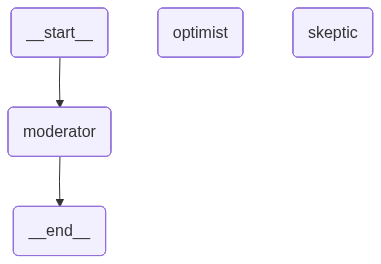

In [29]:
workflow = StateGraph(DebateState)

workflow.add_node("optimist", optimist_node)
workflow.add_node("skeptic", skeptic_node)
workflow.add_node("moderator", moderator_node)

workflow.add_edge(START, 'moderator')
workflow.add_conditional_edges('moderator', moderator_route)
workflow.add_edge('optimist', 'skeptic')
workflow.add_edge('skeptic', 'moderator')

debate_app = workflow.compile()
debate_app

In [28]:
init_debate = DebateState(topic='북한 핵 무기 보유는 필요합니다')

for chunk in debate_app.stream(init_debate):
    print(chunk)

{'moderator': {'chat_history': [AIMessage(content='토론 주제는 "북한 핵 무기 보유는 필요하다"입니다. 이제 찬성 측과 반대 측 AI가 각각의 입장을 발표하도록 하겠습니다.\n\n**찬성 측 발언:** 북한의 핵 무기 보유는 국가 안전 보장을 위한 필수적인 수단입니다. 주변 강대국들, 특히 미국과 한국의 군사적 압박에 대항하기 위해서는 핵 억제가 필요합니다. 북한은 핵 무기를 통해 외부의 침략으로부터 스스로를 방어할 수 있으며, 이는 자국의 주권을 지키는 방법입니다.\n\n**반대 측 발언:** 북한의 핵 무기 보유는 오히려 국가 안전을 위협하는 요소입니다. 국제 사회의 제재와 고립을 초래하며, 주변 국가들과의 갈등을 증대시킵니다. 핵 무기는 사용될 경우 인류에 대한 재앙이 될 수 있으며, 평화적인 해결책을 모색하는 대신 군사적 긴장을 증대시키는 결과를 초래합니다.\n\n**찬성 측 발언 요약:** 북한의 핵 보유는 외부의 군사적 압박에 대응하기 위한 자위책이다.\n\n**반대 측 발언 요약:** 북한의 핵 보유는 갈등을 일으키고 국제 사회에서 고립을 초래하는 위험한 요소이다. \n\n이제 찬성 측의 추가 발언을 요청하겠습니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 310, 'prompt_tokens': 122, 'total_tokens': 432, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider'